# VIX Futures Roll Trading Strategy — Full Backtest

**Based on Buehler & Cusatis (2018)**

1. Load & clean VIX futures data (inc. pre-2008 ÷10 fix)
2. Replicate Buehler OOS (Oct 2011 – Dec 2016)
3. Train until end-2016, test 2017+ (Volmageddon & COVID out-of-sample)
4. Portfolio blend: SPX + Vol strategy with weight optimisation

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import os, glob, re, warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

try:
    import yfinance as yf
except ImportError:
    !pip install yfinance
    import yfinance as yf

print('All imports OK')

All imports OK


## 2. Configuration

In [2]:
VIX_FUTURES_DIR = 'data/vix_futures'

BUEHLER_SHORT =  0.0197
BUEHLER_LONG  = -0.2400

BUEHLER_OOS_START = '2011-10-04'
BUEHLER_OOS_END   = '2016-12-30'

# Train/test split for our own optimisation
TRAIN_END   = '2016-12-30'
TEST_START  = '2017-01-03'

MONTH_CODES = {
    'F':1,'G':2,'H':3,'J':4,'K':5,'M':6,
    'N':7,'Q':8,'U':9,'V':10,'X':11,'Z':12
}

print('Config loaded.')

Config loaded.


## 3. Load VIX Futures Data (with pre-2008 price fix)

The old CBOE archive files (2006–2007) have settle/close prices that are ~10× too high
(e.g. 130–216 instead of 13–21.6). We detect and correct this by dividing by 10
whenever a row's settle price exceeds 90 (the VIX has never closed above ~83).
This is done **per-row** rather than per-contract, because some contracts have mixed
scaling (10× early on, normal prices near expiry).

In [3]:
def parse_expiration_from_filename(fname):
    base = os.path.basename(fname)
    m = re.match(r'VX_(\d{4}-\d{2}-\d{2})\.csv', base)
    if m:
        return pd.Timestamp(m.group(1))
    m = re.match(r'CFE_([A-Z])(\d{2})_VX\.csv', base)
    if m:
        month_code, yy = m.group(1), int(m.group(2))
        year = 2000 + yy
        month = MONTH_CODES.get(month_code)
        if month is None:
            return None
        first_day = pd.Timestamp(year, month, 1)
        wed_offset = (2 - first_day.weekday()) % 7
        third_wed = first_day + pd.Timedelta(days=wed_offset + 14)
        return third_wed
    return None


def load_single_contract(fpath):
    try:
        df = pd.read_csv(fpath)
    except Exception:
        return None
    df.columns = df.columns.str.strip()
    if df['Trade Date'].str.contains('/').any():
        df['Trade Date'] = pd.to_datetime(df['Trade Date'], format='%m/%d/%Y')
    else:
        df['Trade Date'] = pd.to_datetime(df['Trade Date'])
    df = df.rename(columns={'Trade Date': 'date'})
    expiry = parse_expiration_from_filename(fpath)
    if expiry is None:
        return None
    df['expiry'] = expiry
    
    # Use Settle, fall back to Close when Settle is 0 (early 2013 files)
    df['Settle'] = pd.to_numeric(df['Settle'], errors='coerce')
    df['Close']  = pd.to_numeric(df['Close'], errors='coerce')
    df['Settle'] = df['Settle'].where(df['Settle'] > 0, df['Close'])
    df = df[df['Settle'] > 0].copy()
    
    # ── Pre-2008 fix: divide by 10 on a PER-ROW basis ──
    # The VIX has never closed above ~83, so any individual row
    # with Settle > 90 is at 10× scale and needs dividing.
    # (Per-contract median failed because some contracts had
    #  mixed scaling: 10× early on, normal near expiry.)
    mask_scaled = df['Settle'] > 90
    df.loc[mask_scaled, 'Settle'] = df.loc[mask_scaled, 'Settle'] / 10.0
    df['_n_scaled'] = mask_scaled.sum()
    
    return df[['date', 'expiry', 'Settle', 'Total Volume', 'Open Interest', '_n_scaled']].copy()


all_files = sorted(glob.glob(os.path.join(VIX_FUTURES_DIR, '*.csv')))
print(f'Found {len(all_files)} VIX futures CSV files')

frames = []
total_rows_scaled = 0
for f in all_files:
    df = load_single_contract(f)
    if df is not None and len(df) > 0:
        total_rows_scaled += df['_n_scaled'].iloc[0]
        frames.append(df)

futures_all = pd.concat(frames, ignore_index=True)
futures_all = futures_all.sort_values(['date', 'expiry']).reset_index(drop=True)

print(f'Total rows: {len(futures_all):,}')
print(f'Date range: {futures_all.date.min().date()} to {futures_all.date.max().date()}')
print(f'Total individual rows with ÷10 fix: {total_rows_scaled}')

# Sanity check: no settle > 90 should remain
bad = futures_all[futures_all['Settle'] > 90]
if len(bad) > 0:
    print(f'⚠️ WARNING: {len(bad)} rows still have Settle > 90!')
else:
    print('✅ All settle prices ≤ 90 after fix')

Found 252 VIX futures CSV files
Total rows: 43,908
Date range: 2005-05-23 to 2026-04-01
Total individual rows with ÷10 fix: 2448
✅ All settle prices ≤ 90 after fix


## 4. Validate Pre-2008 Data After Fix

In [4]:
# Show yearly stats to verify the fix looks sensible
print(f'{"Year":>6} {"Days":>5} {"Contracts":>10} {"F_min":>7} {"F_med":>7} {"F_max":>7}')
for yr in range(2006, 2010):
    chunk = futures_all[futures_all['date'].dt.year == yr]
    if len(chunk) == 0:
        continue
    s = chunk['Settle']
    print(f'{yr:>6} {chunk["date"].nunique():>5} {chunk["expiry"].nunique():>10} '
          f'{s.min():>7.1f} {s.median():>7.1f} {s.max():>7.1f}')

# Compare 2006-07 to 2008-09: the ranges should be broadly similar
print('\n(For reference: VIX spot ranged 10-33 in 2006-07, 16-81 in 2008-09)')

  Year  Days  Contracts   F_min   F_med   F_max
  2006   251         21    10.1    15.3    21.6
  2007   251         21    10.0    16.3    30.6
  2008   253         22     1.0    24.6    68.0
  2009   252         20    20.8    30.6    57.9

(For reference: VIX spot ranged 10-33 in 2006-07, 16-81 in 2008-09)


## 5. Build Daily Term Structure

In [5]:
def build_term_structure(futures_all):
    df = futures_all[futures_all['expiry'] > futures_all['date']].copy()
    df['dte'] = (df['expiry'] - df['date']).dt.days
    records = []
    for date, group in df.groupby('date'):
        g = group.sort_values('expiry')
        if len(g) < 2:
            continue
        f1, f2 = g.iloc[0], g.iloc[1]
        records.append({
            'date': date,
            'F1_settle': f1['Settle'], 'F1_expiry': f1['expiry'], 'F1_dte': f1['dte'],
            'F2_settle': f2['Settle'], 'F2_expiry': f2['expiry'], 'F2_dte': f2['dte'],
        })
    ts = pd.DataFrame(records)
    ts['date'] = pd.to_datetime(ts['date'])
    ts = ts.set_index('date').sort_index()
    return ts

term_structure = build_term_structure(futures_all)
print(f'Term structure: {len(term_structure)} trading days')
print(f'Range: {term_structure.index.min().date()} to {term_structure.index.max().date()}')

# Check for remaining gaps
all_bdays = pd.bdate_range(term_structure.index.min(), term_structure.index.max())
missing = all_bdays.difference(term_structure.index)
print(f'Missing business days: {len(missing)}')

Term structure: 5161 trading days
Range: 2005-08-22 to 2026-04-01
Missing business days: 217


## 6. Download VIX Spot & ETF Prices

In [6]:
def dl(ticker, start='2004-01-01', end='2026-12-31'):
    tmp = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    tmp = tmp[['Close']]
    if isinstance(tmp.columns, pd.MultiIndex):
        tmp.columns = tmp.columns.get_level_values(0)
    tmp.index = pd.to_datetime(tmp.index)
    if hasattr(tmp.index, 'levels'):
        tmp.index = tmp.index.get_level_values(0)
    tmp.index.name = 'date'
    return tmp

vix  = dl('^VIX').rename(columns={'Close': 'VIX'})
svxy = dl('SVXY').rename(columns={'Close': 'SVXY'})
vixy = dl('VIXY').rename(columns={'Close': 'VIXY'})
spy  = dl('SPY').rename(columns={'Close': 'SPY'})

for name, df in [('VIX', vix), ('SVXY', svxy), ('VIXY', vixy), ('SPY', spy)]:
    print(f'{name:5s}: {len(df)} rows, {df.index.min().date()} to {df.index.max().date()}')

VIX  : 5598 rows, 2004-01-02 to 2026-04-02
SVXY : 3645 rows, 2011-10-04 to 2026-04-02
VIXY : 3834 rows, 2011-01-04 to 2026-04-02
SPY  : 5598 rows, 2004-01-02 to 2026-04-02


## 7. Merge All Data & Compute Daily Roll

In [7]:
data = term_structure.join(vix, how='inner')
data = data.join(svxy, how='left').join(vixy, how='left').join(spy, how='left')

# Trading days to expiry
data['F1_tdte'] = data.apply(
    lambda r: max(np.busday_count(r.name.date(), r['F1_expiry'].date()), 1), axis=1
)

# Daily roll: (F1 - VIX) / trading days to settlement
# Positive in contango, negative in backwardation
data['daily_roll'] = (data['F1_settle'] - data['VIX']) / data['F1_tdte']

# ETF daily returns
data['SVXY_ret'] = data['SVXY'].pct_change()
data['VIXY_ret'] = data['VIXY'].pct_change()
data['SPY_ret']  = data['SPY'].pct_change()

# Futures return — only on same-contract days (exclude roll-day jumps)
data['F1_ret_raw'] = data['F1_settle'].pct_change()
data['F1_same_contract'] = data['F1_expiry'] == data['F1_expiry'].shift(1)
data['F1_ret'] = data['F1_ret_raw'].where(data['F1_same_contract'], 0.0)

print(f'Merged dataset: {len(data)} rows')
print(f'Range: {data.index.min().date()} to {data.index.max().date()}')

Merged dataset: 5158 rows
Range: 2005-08-22 to 2026-04-01


## 8. VIX Spot vs Nearest Futures & Daily Roll

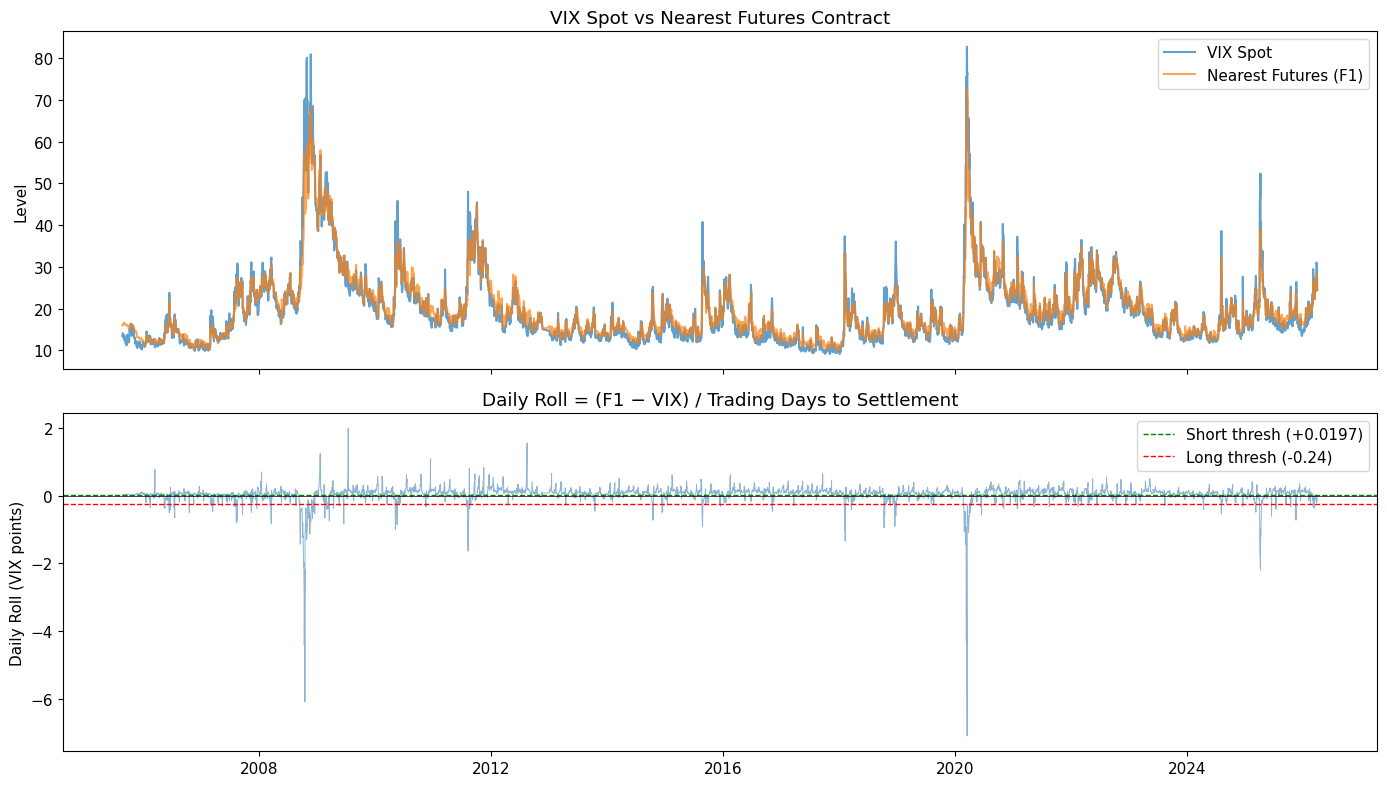

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(data.index, data['VIX'], label='VIX Spot', alpha=0.7)
axes[0].plot(data.index, data['F1_settle'], label='Nearest Futures (F1)', alpha=0.7)
axes[0].set_ylabel('Level')
axes[0].legend()
axes[0].set_title('VIX Spot vs Nearest Futures Contract')

axes[1].plot(data.index, data['daily_roll'], color='steelblue', alpha=0.6, lw=0.7)
axes[1].axhline(BUEHLER_SHORT, color='green', ls='--', lw=1, label=f'Short thresh (+{BUEHLER_SHORT})')
axes[1].axhline(BUEHLER_LONG, color='red', ls='--', lw=1, label=f'Long thresh ({BUEHLER_LONG})')
axes[1].axhline(0, color='black', ls='-', lw=0.5)
axes[1].set_ylabel('Daily Roll (VIX points)')
axes[1].set_title('Daily Roll = (F1 − VIX) / Trading Days to Settlement')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Strategy Engine

In [9]:
def generate_signals(data, short_thresh, long_thresh):
    prev_roll = data['daily_roll'].shift(1)
    signal = pd.Series('CASH', index=data.index)
    signal[prev_roll >= short_thresh] = 'SVXY'
    signal[prev_roll <= long_thresh]  = 'VIXY'
    return signal


def backtest(data, signal, label='Strategy', start=None, end=None):
    df = data.loc[start:end].copy() if start else data.copy()
    sig = signal.reindex(df.index).fillna('CASH')
    df['signal'] = sig
    df = df.dropna(subset=['SVXY_ret', 'VIXY_ret'])
    if len(df) == 0:
        return pd.DataFrame(), {}
    
    # ETF strategy returns
    df['etf_ret'] = 0.0
    df.loc[df['signal'] == 'SVXY', 'etf_ret'] = df.loc[df['signal'] == 'SVXY', 'SVXY_ret']
    df.loc[df['signal'] == 'VIXY', 'etf_ret'] = df.loc[df['signal'] == 'VIXY', 'VIXY_ret']
    
    # Futures strategy returns
    df['fut_ret'] = 0.0
    df.loc[df['signal'] == 'SVXY', 'fut_ret'] = -df.loc[df['signal'] == 'SVXY', 'F1_ret']
    df.loc[df['signal'] == 'VIXY', 'fut_ret'] = df.loc[df['signal'] == 'VIXY', 'F1_ret']
    
    # Equity curves
    df['etf_equity'] = (1 + df['etf_ret']).cumprod()
    df['fut_equity'] = (1 + df['fut_ret']).cumprod()
    df['spy_equity'] = (1 + df['SPY_ret']).cumprod()
    
    # Stats
    n = len(df); yrs = n / 252
    terminal = df['etf_equity'].iloc[-1]
    cagr = terminal ** (1/yrs) - 1 if yrs > 0 else 0
    vol = df['etf_ret'].std() * np.sqrt(252)
    sharpe = (df['etf_ret'].mean() * 252) / vol if vol > 0 else 0
    semi = df['etf_ret'][df['etf_ret'] < 0].std() * np.sqrt(252)
    sortino = (df['etf_ret'].mean() * 252) / semi if semi > 0 else 0
    dd = (df['etf_equity'] / df['etf_equity'].cummax()) - 1
    n_trades = (df['signal'] != df['signal'].shift(1)).sum()
    
    stats = {
        'Terminal ($1)': f'{terminal:.2f}',
        'CAGR': f'{cagr:.1%}', 'Vol (ann.)': f'{vol:.1%}',
        'Sharpe': f'{sharpe:.2f}', 'Sortino': f'{sortino:.2f}',
        'Max DD': f'{dd.min():.1%}',
        'Trades': n_trades,
        'Days Short': (df['signal']=='SVXY').sum(),
        'Days Long': (df['signal']=='VIXY').sum(),
        'Days Cash': (df['signal']=='CASH').sum(),
        'Period': f"{df.index.min().date()} to {df.index.max().date()}",
    }
    return df, stats

print('Engine ready.')

Engine ready.


## 10. Buehler Replication (Oct 2011 – Dec 2016)

Using the published thresholds (+0.0197 / −0.240).

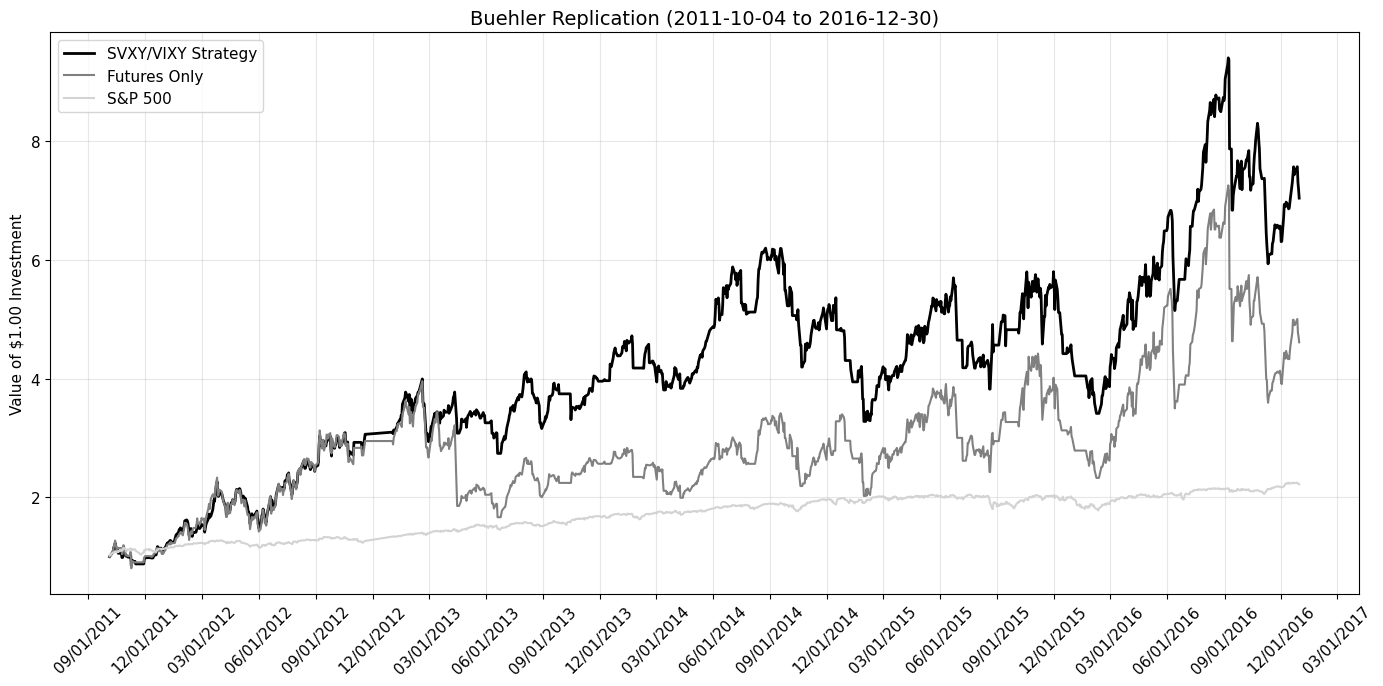


=== Buehler Replication Stats ===
  Terminal ($1)       : 7.04
  CAGR                : 46.3%
  Vol (ann.)          : 53.8%
  Sharpe              : 0.98
  Sortino             : 1.10
  Max DD              : -47.1%
  Trades              : 159
  Days Short          : 1056
  Days Long           : 23
  Days Cash           : 213
  Period              : 2011-10-05 to 2016-12-30


In [10]:
sig_buehler = generate_signals(data, BUEHLER_SHORT, BUEHLER_LONG)
bt_b, stats_b = backtest(data, sig_buehler, 'Buehler ETF',
                          start=BUEHLER_OOS_START, end=BUEHLER_OOS_END)

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(bt_b.index, bt_b['etf_equity'], 'k-', lw=2, label='SVXY/VIXY Strategy')
ax.plot(bt_b.index, bt_b['fut_equity'], color='gray', lw=1.5, label='Futures Only')
ax.plot(bt_b.index, bt_b['spy_equity'], color='lightgray', lw=1.5, label='S&P 500')
ax.set_title(f'Buehler Replication ({BUEHLER_OOS_START} to {BUEHLER_OOS_END})', fontsize=14)
ax.set_ylabel('Value of $1.00 Investment')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\n=== Buehler Replication Stats ===')
for k, v in stats_b.items():
    print(f'  {k:20s}: {v}')

## 11. Threshold Optimisation (80/20 Train/Test Split)

Grid search optimising **Sharpe ratio** on the first 80% of ETF data.
The last 20% is held out for out-of-sample testing.

ETF data: 2011-10-04 to 2026-04-01 (3617 days)
Train (80%): 2011-10-04 to 2023-05-11 (2893 days)
Test  (20%): 2023-05-12 to 2026-04-01 (724 days)
  Volmageddon: ❌ in train
  COVID: ❌ in train

=== Optimal Thresholds (Train Set, max Sharpe) ===
  Short: 0.0300  (Buehler: 0.0197)
  Long:  -0.5000  (Buehler: -0.24)
  Sharpe: 1.160
  Terminal: $118.12
  Max DD: -36.7%


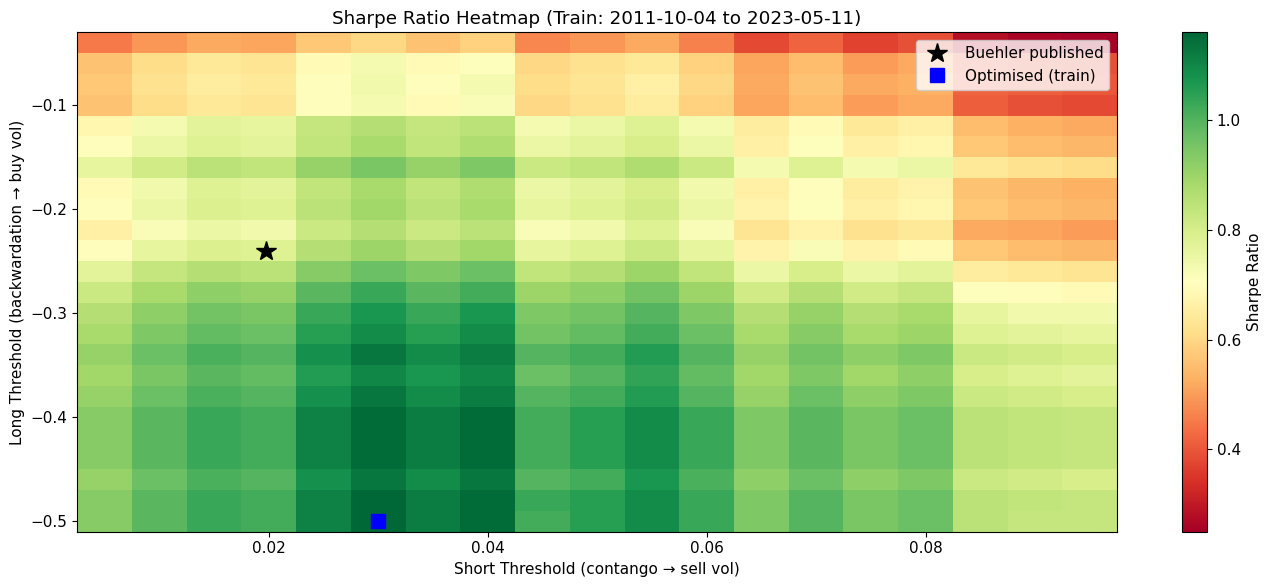

In [11]:
etf_data = data.dropna(subset=['SVXY', 'VIXY']).copy()
etf_start = etf_data.index.min().strftime('%Y-%m-%d')

# 80/20 split
split_idx = int(len(etf_data) * 0.80)
train_end = etf_data.index[split_idx - 1]
test_start = etf_data.index[split_idx]
train_end_str = train_end.strftime('%Y-%m-%d')
test_start_str = test_start.strftime('%Y-%m-%d')

print(f'ETF data: {etf_start} to {etf_data.index.max().date()} ({len(etf_data)} days)')
print(f'Train (80%): {etf_start} to {train_end.date()} ({split_idx} days)')
print(f'Test  (20%): {test_start.date()} to {etf_data.index.max().date()} ({len(etf_data) - split_idx} days)')

# Check key events
for evt, dt in [('Volmageddon', '2018-02-05'), ('COVID', '2020-03-16')]:
    print(f'  {evt}: {"✅ OOS" if pd.Timestamp(dt) >= test_start else "❌ in train"}')

short_grid = np.arange(0.005, 0.10, 0.005)
long_grid  = np.arange(-0.50, -0.02, 0.02)

results = []
for st in short_grid:
    for lt in long_grid:
        sig = generate_signals(data, st, lt)
        bt_tmp, stats_tmp = backtest(data, sig, '', start=etf_start, end=train_end_str)
        if len(bt_tmp) == 0:
            continue
        results.append({
            'short_thresh': round(st, 4),
            'long_thresh': round(lt, 4),
            'sharpe': float(stats_tmp['Sharpe']),
            'terminal': bt_tmp['etf_equity'].iloc[-1],
            'max_dd': (bt_tmp['etf_equity'] / bt_tmp['etf_equity'].cummax() - 1).min(),
        })

res_df = pd.DataFrame(results)
best = res_df.loc[res_df['sharpe'].idxmax()]
OPT_SHORT = best['short_thresh']
OPT_LONG  = best['long_thresh']

print(f'\n=== Optimal Thresholds (Train Set, max Sharpe) ===')
print(f'  Short: {OPT_SHORT:.4f}  (Buehler: {BUEHLER_SHORT})')
print(f'  Long:  {OPT_LONG:.4f}  (Buehler: {BUEHLER_LONG})')
print(f'  Sharpe: {best["sharpe"]:.3f}')
print(f'  Terminal: ${best["terminal"]:.2f}')
print(f'  Max DD: {best["max_dd"]:.1%}')

# Heatmap
pivot = res_df.pivot_table(values='sharpe', index='long_thresh', columns='short_thresh')
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.pcolormesh(pivot.columns, pivot.index, pivot.values, cmap='RdYlGn', shading='auto')
ax.plot(BUEHLER_SHORT, BUEHLER_LONG, 'k*', markersize=15, label='Buehler published')
ax.plot(OPT_SHORT, OPT_LONG, 'bs', markersize=10, label='Optimised (train)')
ax.set_xlabel('Short Threshold (contango → sell vol)')
ax.set_ylabel('Long Threshold (backwardation → buy vol)')
ax.set_title(f'Sharpe Ratio Heatmap (Train: {etf_start} to {train_end_str})')
ax.legend(fontsize=11)
plt.colorbar(im, label='Sharpe Ratio')
plt.tight_layout()
plt.show()

## 12. Out-of-Sample Test (2017 – Present)

Both **Volmageddon (Feb 2018)** and **COVID (Mar 2020)** are fully out-of-sample.
We compare our optimised thresholds to Buehler's original ones.

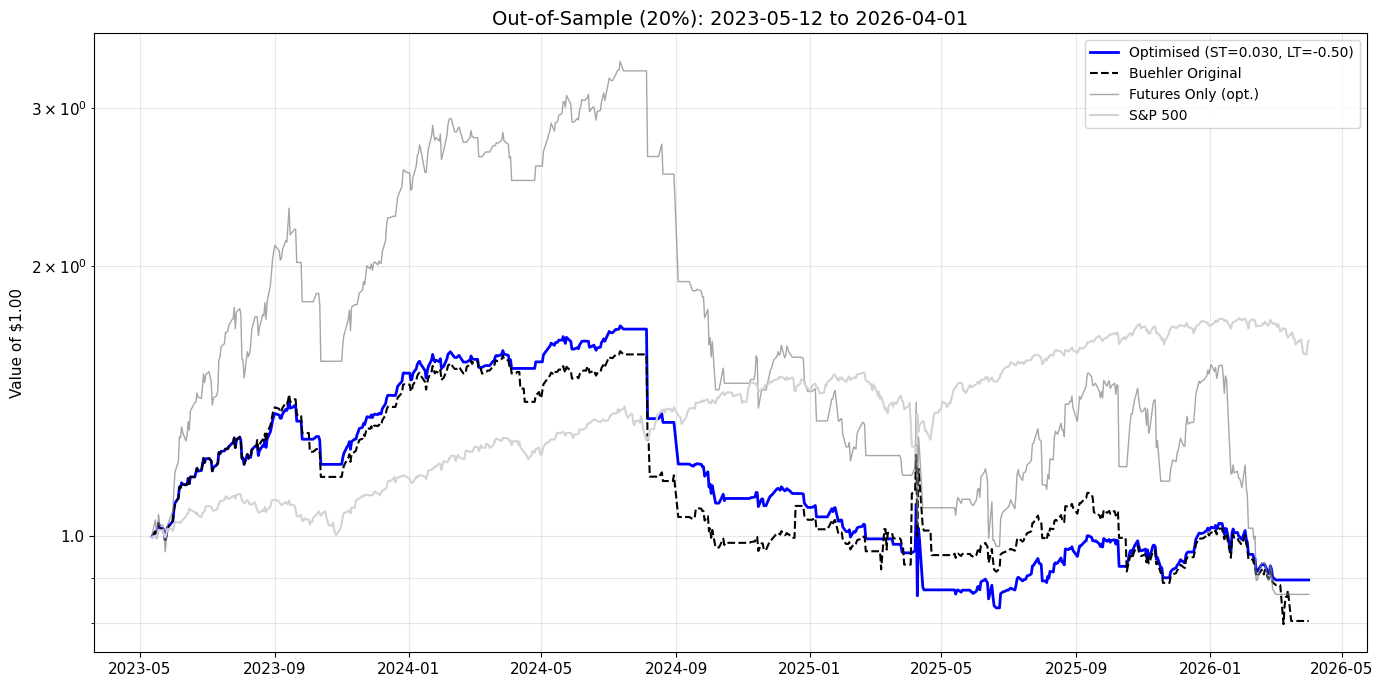


=== Out-of-Sample Results ===


,Terminal ($1),CAGR,Vol (ann.),Sharpe,Sortino,Max DD,Trades,Days Short,Days Long,Days Cash,Period
Optimised,0.89,-3.8%,29.9%,0.03,0.02,-51.5%,116,464,10,250,2023-05-12 to 2026-04-01
Buehler Original,0.81,-7.3%,35.8%,-0.03,-0.02,-50.3%,129,487,28,209,2023-05-12 to 2026-04-01


In [12]:
test_end = etf_data.index.max().strftime('%Y-%m-%d')

sig_opt = generate_signals(data, OPT_SHORT, OPT_LONG)
bt_opt, stats_opt = backtest(data, sig_opt, 'Optimised', start=test_start_str, end=test_end)

sig_buehler_test = generate_signals(data, BUEHLER_SHORT, BUEHLER_LONG)
bt_buehler_test, stats_buehler_test = backtest(data, sig_buehler_test, 'Buehler',
                                                start=test_start_str, end=test_end)

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(bt_opt.index, bt_opt['etf_equity'], 'b-', lw=2,
        label=f'Optimised (ST={OPT_SHORT:.3f}, LT={OPT_LONG:.2f})')
ax.plot(bt_buehler_test.index, bt_buehler_test['etf_equity'], 'k--', lw=1.5,
        label='Buehler Original')
ax.plot(bt_opt.index, bt_opt['fut_equity'], color='gray', lw=1, alpha=0.7,
        label='Futures Only (opt.)')
ax.plot(bt_opt.index, bt_opt['spy_equity'], color='lightgray', lw=1.5, label='S&P 500')

for dt, lbl in [('2018-02-05', 'Volmageddon'), ('2020-03-16', 'COVID')]:
    evt = pd.Timestamp(dt)
    if evt >= bt_opt.index.min() and evt <= bt_opt.index.max():
        ax.axvline(evt, color='red', ls=':', alpha=0.5)
        ax.text(evt, ax.get_ylim()[1]*0.85, f' {lbl}', fontsize=9, color='red')

ax.set_title(f'Out-of-Sample (20%): {test_start_str} to {test_end}', fontsize=14)
ax.set_ylabel('Value of $1.00')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

comp = pd.DataFrame({'Optimised': stats_opt, 'Buehler Original': stats_buehler_test}).T
print('\n=== Out-of-Sample Results ===')
display(comp)

## 13. Full Period Equity Curve (Train + Test)

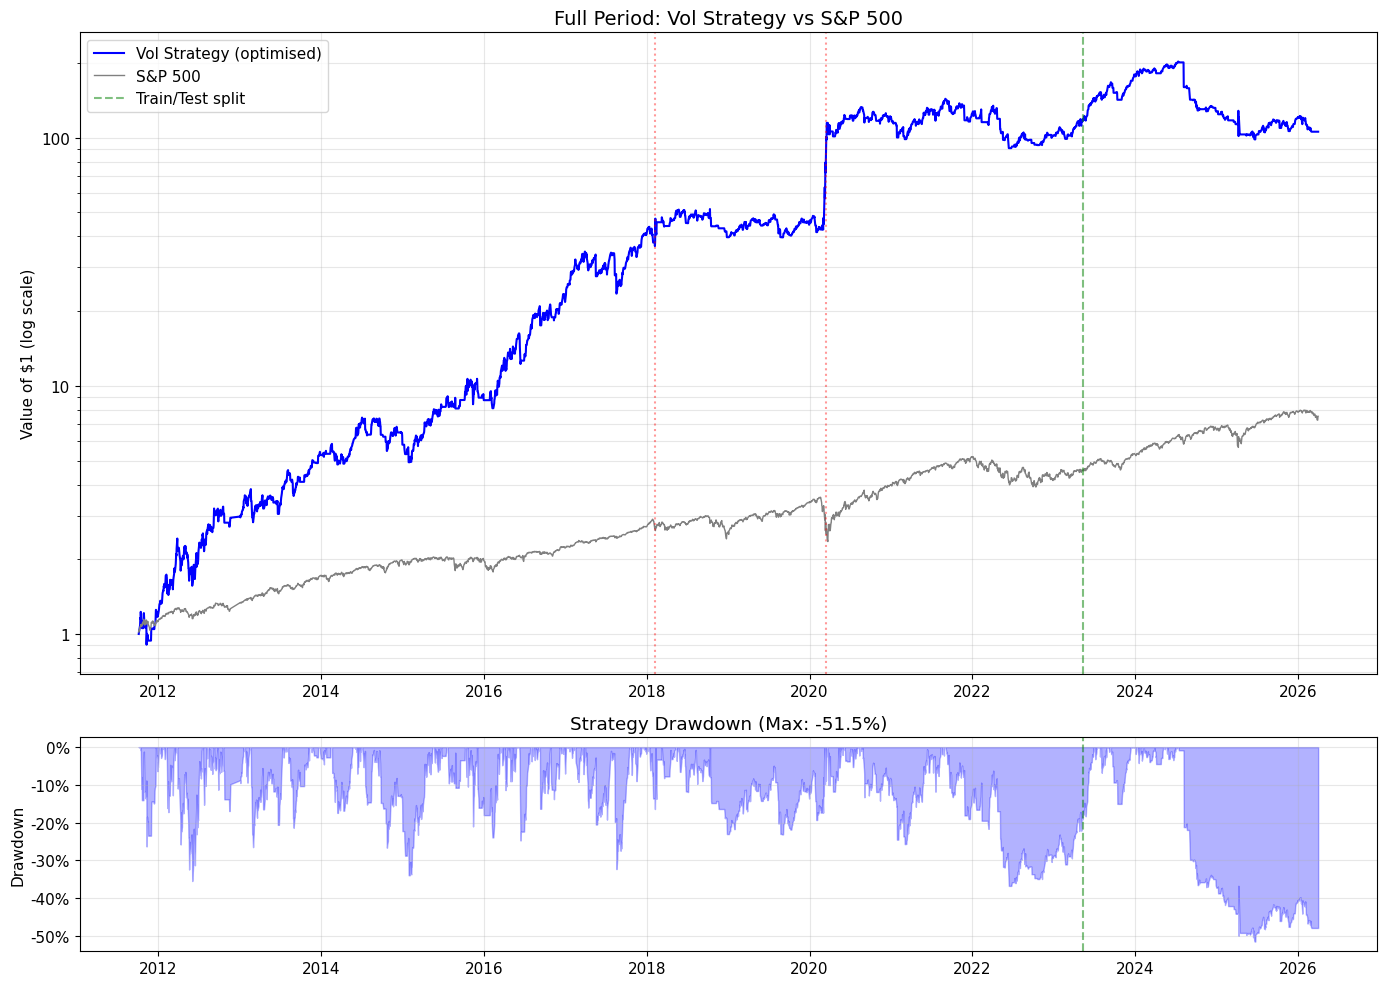


=== Full Period Stats ===
  Terminal ($1)       : 105.64
  CAGR                : 38.4%
  Vol (ann.)          : 42.0%
  Sharpe              : 0.98
  Sortino             : 1.02
  Max DD              : -51.5%
  Trades              : 530
  Days Short          : 2590
  Days Long           : 46
  Days Cash           : 980
  Period              : 2011-10-05 to 2026-04-01


In [13]:
full_start = etf_data.index.min().strftime('%Y-%m-%d')
full_end = etf_data.index.max().strftime('%Y-%m-%d')

bt_full, stats_full = backtest(data, sig_opt, 'Full', start=full_start, end=full_end)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[3, 1])

ax = axes[0]
ax.plot(bt_full.index, bt_full['etf_equity'], 'b-', lw=1.5, label='Vol Strategy (optimised)')
ax.plot(bt_full.index, bt_full['spy_equity'], color='gray', lw=1, label='S&P 500')
ax.axvline(train_end, color='green', ls='--', alpha=0.5, label='Train/Test split')
for dt, lbl in [('2018-02-05', 'Volmageddon'), ('2020-03-16', 'COVID')]:
    evt = pd.Timestamp(dt)
    if evt >= bt_full.index.min():
        ax.axvline(evt, color='red', ls=':', alpha=0.4)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.0f}'))
ax.set_title('Full Period: Vol Strategy vs S&P 500', fontsize=14)
ax.set_ylabel('Value of $1 (log scale)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')

ax2 = axes[1]
eq = bt_full['etf_equity']
dd = (eq / eq.cummax()) - 1
ax2.fill_between(dd.index, dd.values, 0, color='blue', alpha=0.3)
ax2.axvline(train_end, color='green', ls='--', alpha=0.5)
ax2.set_ylabel('Drawdown')
ax2.set_title(f'Strategy Drawdown (Max: {dd.min():.1%})')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\n=== Full Period Stats ===')
for k, v in stats_full.items():
    print(f'  {k:20s}: {v}')

## 14. Portfolio: S&P 500 + Vol Strategy

Blend with constant daily rebalancing. Scan 0–50% vol strategy weight
(beyond 50% is impractical for most investors).
Find weights that maximise Sharpe and minimise max drawdown.

=== Optimal Portfolio Weights ===

Max Sharpe: 31% Vol + 69% SPY
  Sharpe=1.24, CAGR=24.2%, Max DD=-25.1%

Min Drawdown: 8% Vol + 92% SPY
  Sharpe=1.07, CAGR=17.6%, Max DD=-24.5%


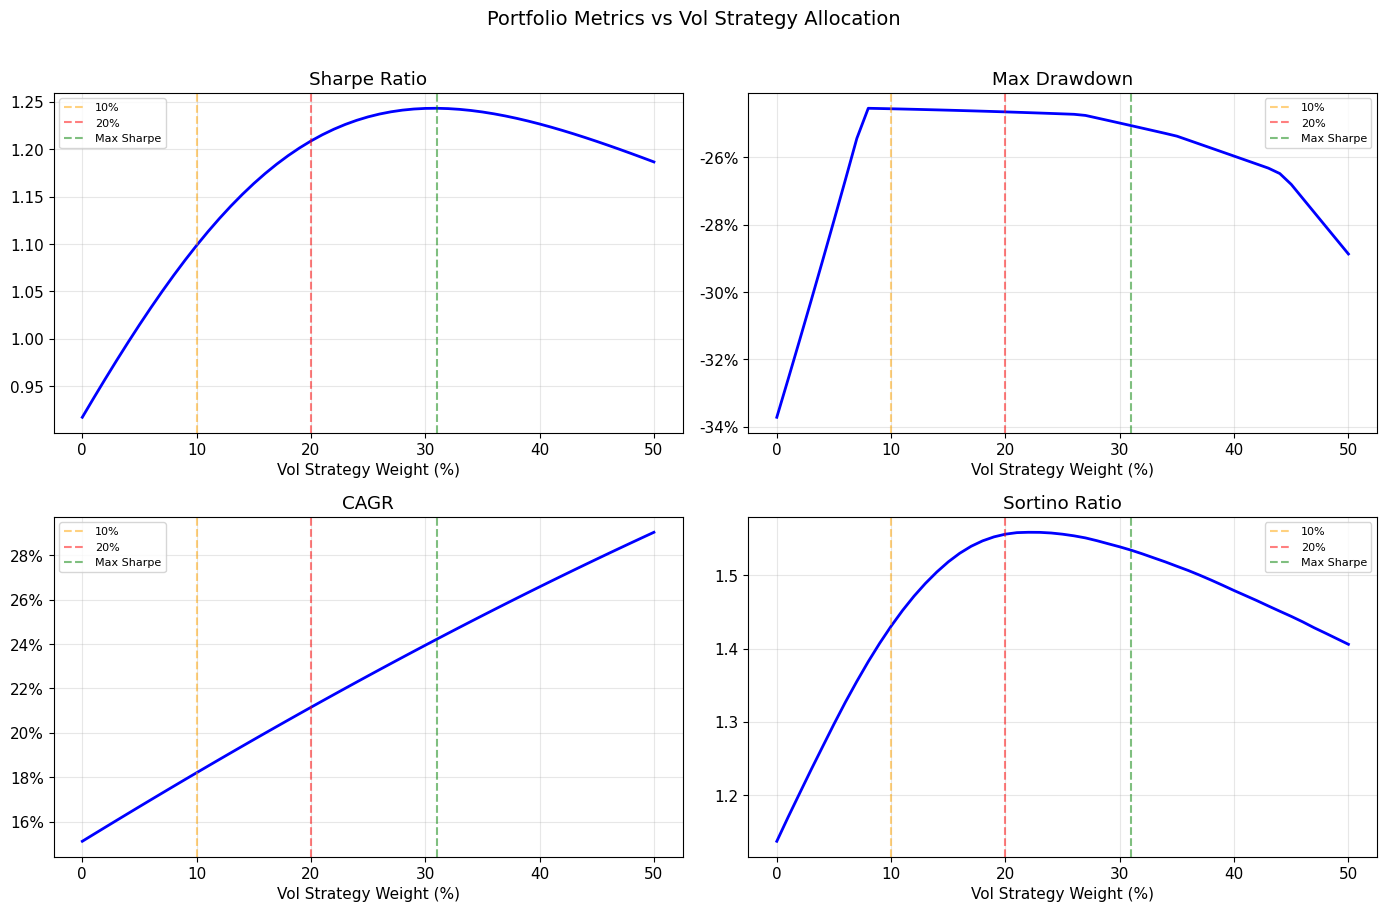

In [14]:
port_data = bt_full[['etf_ret', 'SPY_ret']].dropna().copy()

weights = np.arange(0.0, 0.51, 0.01)
port_results = []

for w_vol in weights:
    w_spy = 1 - w_vol
    port_ret = w_vol * port_data['etf_ret'] + w_spy * port_data['SPY_ret']
    port_eq = (1 + port_ret).cumprod()
    n_yrs = len(port_ret) / 252
    terminal = port_eq.iloc[-1]
    cagr = terminal ** (1/n_yrs) - 1
    vol = port_ret.std() * np.sqrt(252)
    sharpe = (port_ret.mean() * 252) / vol if vol > 0 else 0
    dd = (port_eq / port_eq.cummax() - 1).min()
    semi = port_ret[port_ret < 0].std() * np.sqrt(252)
    sortino = (port_ret.mean() * 252) / semi if semi > 0 else 0
    port_results.append({
        'w_vol': w_vol, 'w_spy': w_spy,
        'cagr': cagr, 'vol': vol, 'sharpe': sharpe,
        'sortino': sortino, 'max_dd': dd, 'terminal': terminal,
    })

port_df = pd.DataFrame(port_results)
best_sharpe = port_df.loc[port_df['sharpe'].idxmax()]
best_dd = port_df.loc[port_df['max_dd'].idxmax()]

print('=== Optimal Portfolio Weights ===')
print(f'\nMax Sharpe: {best_sharpe["w_vol"]:.0%} Vol + {best_sharpe["w_spy"]:.0%} SPY')
print(f'  Sharpe={best_sharpe["sharpe"]:.2f}, CAGR={best_sharpe["cagr"]:.1%}, '
      f'Max DD={best_sharpe["max_dd"]:.1%}')
print(f'\nMin Drawdown: {best_dd["w_vol"]:.0%} Vol + {best_dd["w_spy"]:.0%} SPY')
print(f'  Sharpe={best_dd["sharpe"]:.2f}, CAGR={best_dd["cagr"]:.1%}, '
      f'Max DD={best_dd["max_dd"]:.1%}')

# ── Metrics vs weight ──
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, metric, title in [
    (axes[0,0], 'sharpe', 'Sharpe Ratio'),
    (axes[0,1], 'max_dd', 'Max Drawdown'),
    (axes[1,0], 'cagr', 'CAGR'),
    (axes[1,1], 'sortino', 'Sortino Ratio'),
]:
    ax.plot(port_df['w_vol'] * 100, port_df[metric], 'b-', lw=2)
    ax.set_xlabel('Vol Strategy Weight (%)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.axvline(10, color='orange', ls='--', alpha=0.5, label='10%')
    ax.axvline(20, color='red', ls='--', alpha=0.5, label='20%')
    ax.axvline(best_sharpe['w_vol'] * 100, color='green', ls='--', alpha=0.5, label='Max Sharpe')
    if metric in ['max_dd', 'cagr']:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.legend(fontsize=8)

plt.suptitle('Portfolio Metrics vs Vol Strategy Allocation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 15. Portfolio Equity Curves

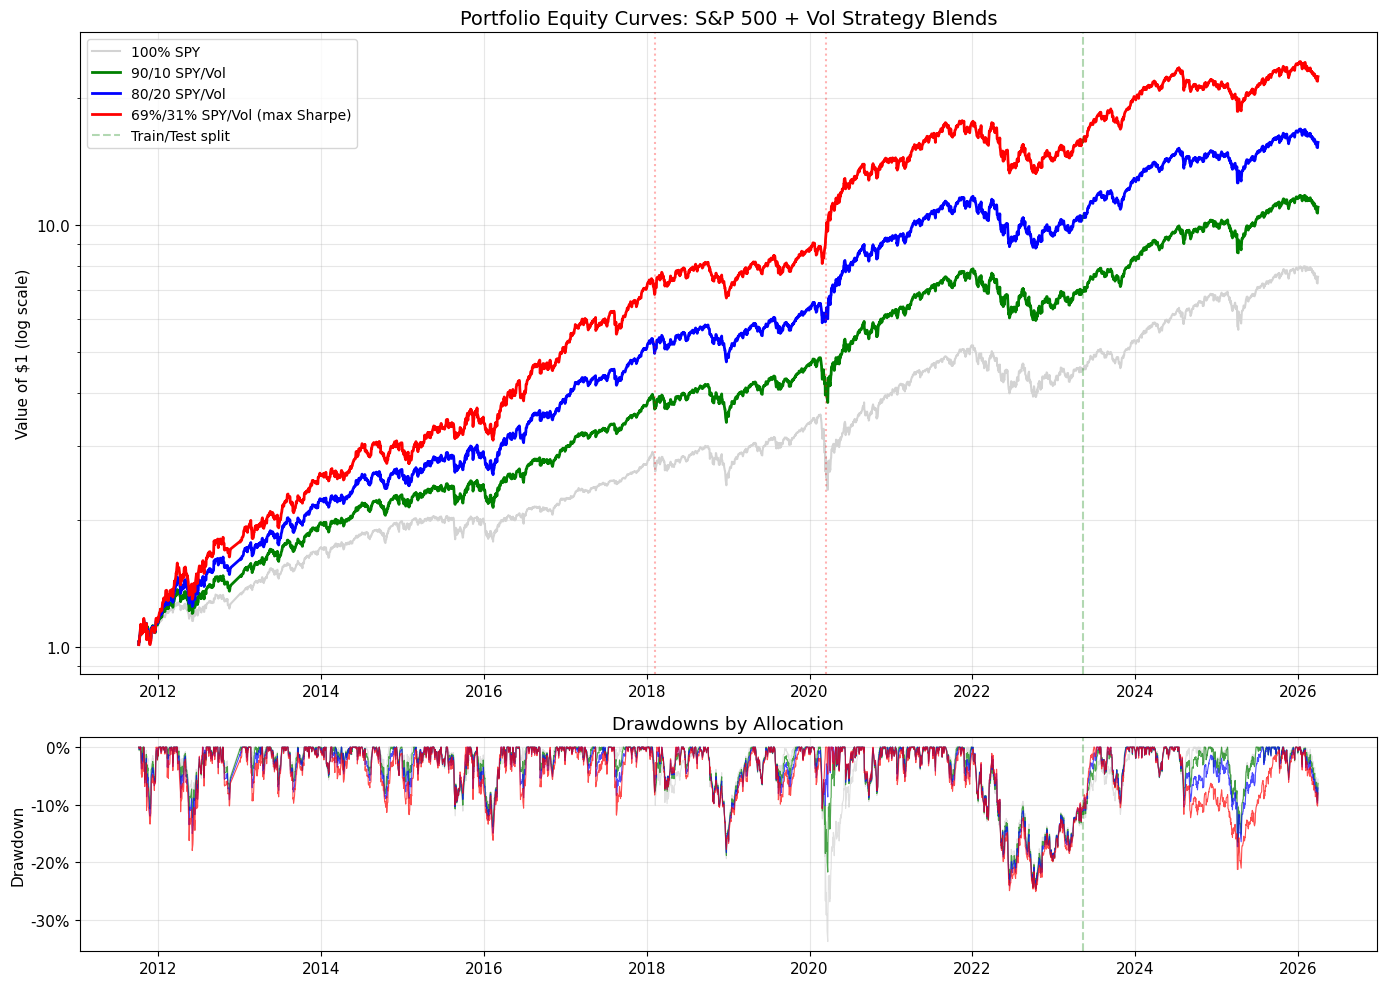

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[3, 1])

allocations = [
    (0.00, '100% SPY', 'lightgray'),
    (0.10, '90/10 SPY/Vol', 'green'),
    (0.20, '80/20 SPY/Vol', 'blue'),
    (best_sharpe['w_vol'],
     f'{best_sharpe["w_spy"]:.0%}/{best_sharpe["w_vol"]:.0%} SPY/Vol (max Sharpe)', 'red'),
]

ax = axes[0]
ax2 = axes[1]

for w_vol, label, color in allocations:
    port_ret = w_vol * port_data['etf_ret'] + (1 - w_vol) * port_data['SPY_ret']
    port_eq = (1 + port_ret).cumprod()
    ax.plot(port_eq.index, port_eq, color=color, lw=2 if w_vol > 0 else 1.5, label=label)
    dd = (port_eq / port_eq.cummax()) - 1
    ax2.plot(dd.index, dd, color=color, lw=0.8, alpha=0.7)

ax.axvline(train_end, color='green', ls='--', alpha=0.3, label='Train/Test split')
for dt, lbl in [('2018-02-05', 'Volmageddon'), ('2020-03-16', 'COVID')]:
    evt = pd.Timestamp(dt)
    if evt >= port_data.index.min():
        ax.axvline(evt, color='red', ls=':', alpha=0.3)

ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}'))
ax.set_title('Portfolio Equity Curves: S&P 500 + Vol Strategy Blends', fontsize=14)
ax.set_ylabel('Value of $1 (log scale)')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3, which='both')

ax2.axvline(train_end, color='green', ls='--', alpha=0.3)
ax2.set_ylabel('Drawdown')
ax2.set_title('Drawdowns by Allocation')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 16. Summary Table — Key Allocations

In [16]:
summary_rows = []
for w_vol, label in [(0.0, '100% SPY'), (0.05, '95/5'), (0.10, '90/10'),
                      (0.15, '85/15'), (0.20, '80/20'),
                      (best_sharpe['w_vol'],
                       f'Max Sharpe ({best_sharpe["w_spy"]:.0%}/{best_sharpe["w_vol"]:.0%})')]:
    row = port_df.iloc[(port_df['w_vol'] - w_vol).abs().idxmin()]
    summary_rows.append({
        'Allocation': label,
        'Vol Wt': f'{row["w_vol"]:.0%}',
        'SPY Wt': f'{row["w_spy"]:.0%}',
        'CAGR': f'{row["cagr"]:.1%}',
        'Vol': f'{row["vol"]:.1%}',
        'Sharpe': f'{row["sharpe"]:.2f}',
        'Sortino': f'{row["sortino"]:.2f}',
        'Max DD': f'{row["max_dd"]:.1%}',
        'Terminal': f'${row["terminal"]:.2f}',
    })

display(pd.DataFrame(summary_rows).set_index('Allocation'))

,Vol Wt,SPY Wt,CAGR,Vol,Sharpe,Sortino,Max DD,Terminal
Allocation,,,,,,,,
100% SPY,0%,100%,15.1%,16.9%,0.92,1.14,-33.7%,$7.54
95/5,5%,95%,16.7%,16.6%,1.01,1.30,-27.9%,$9.14
90/10,10%,90%,18.2%,16.5%,1.10,1.43,-24.6%,$11.02
85/15,15%,85%,19.7%,16.6%,1.16,1.52,-24.6%,$13.19
80/20,20%,80%,21.1%,17.1%,1.21,1.56,-24.6%,$15.69
Max Sharpe (69%/31%),31%,69%,24.2%,18.9%,1.24,1.53,-25.1%,$22.46


---
# Part III: Robustness & Live-Readiness


## 17. Backtest with Realistic Trading Costs (Interactive Brokers)

**IB Tiered pricing (US ETFs):**
- Commission: $0.0035/share, min $0.35, max 1% of trade value
- Bid-ask spread: ~3 bps normal, ~8 bps when VIX > 25

Portfolio: **€20,000** (~$21,500). Adjustable below.

In [17]:
PORTFOLIO_EUR  = 20_000
EUR_USD        = 1.075
PORTFOLIO_USD  = PORTFOLIO_EUR * EUR_USD

COMMISSION_PER_SHARE = 0.0035
MIN_COMMISSION       = 0.35
MAX_COMMISSION_PCT   = 0.01

HALF_SPREAD_NORMAL = 0.0003  # 3 bps
HALF_SPREAD_STRESS = 0.0008  # 8 bps
VIX_STRESS_LEVEL   = 25

print(f'Portfolio: €{PORTFOLIO_EUR:,.0f} = ${PORTFOLIO_USD:,.0f}')

Portfolio: €20,000 = $21,500


In [18]:
def backtest_with_costs(data, signal, portfolio_usd, w_vol=0.30, w_spy=0.70,
                         start=None, end=None):
    """
    Backtest blended portfolio (SPY + vol strategy) with IB trading costs.
    The vol portion switches between SVXY/VIXY/CASH.
    """
    df = data.loc[start:end].copy() if start else data.copy()
    sig = signal.reindex(df.index).fillna('CASH')
    df['signal'] = sig
    df = df.dropna(subset=['SVXY', 'VIXY', 'SPY']).copy()
    if len(df) == 0:
        return pd.DataFrame(), {}
    
    # Compute vol strategy return per row
    df['vol_ret'] = 0.0
    df.loc[df['signal'] == 'SVXY', 'vol_ret'] = df.loc[df['signal'] == 'SVXY', 'SVXY_ret']
    df.loc[df['signal'] == 'VIXY', 'vol_ret'] = df.loc[df['signal'] == 'VIXY', 'VIXY_ret']
    
    vol_alloc = portfolio_usd * w_vol
    spy_alloc = portfolio_usd * w_spy
    
    equity = [portfolio_usd]
    total_costs = 0.0
    n_trades = 0
    cost_list = [0.0]
    prev_signal = 'CASH'
    
    for i in range(1, len(df)):
        row = df.iloc[i]
        prev_row = df.iloc[i-1]
        cur_signal = df['signal'].iloc[i]
        
        spy_pnl = spy_alloc * (row['SPY_ret'] if not np.isnan(row['SPY_ret']) else 0.0)
        vol_pnl = vol_alloc * (row['vol_ret'] if not np.isnan(row['vol_ret']) else 0.0)
        
        # Trading costs on signal change
        trade_cost = 0.0
        if cur_signal != prev_signal:
            n_trades += 1
            vix_now = row['VIX'] if not np.isnan(row['VIX']) else 15
            half_spread = HALF_SPREAD_STRESS if vix_now > VIX_STRESS_LEVEL else HALF_SPREAD_NORMAL
            
            # Exit cost
            if prev_signal != 'CASH':
                exit_px = prev_row['SVXY'] if prev_signal == 'SVXY' else prev_row['VIXY']
                if exit_px > 0 and not np.isnan(exit_px):
                    n_sh = vol_alloc / exit_px
                    comm = max(MIN_COMMISSION, min(n_sh * COMMISSION_PER_SHARE,
                                                   vol_alloc * MAX_COMMISSION_PCT))
                    trade_cost += comm + vol_alloc * half_spread
            
            # Entry cost
            if cur_signal != 'CASH':
                entry_px = row['SVXY'] if cur_signal == 'SVXY' else row['VIXY']
                if entry_px > 0 and not np.isnan(entry_px):
                    n_sh = vol_alloc / entry_px
                    comm = max(MIN_COMMISSION, min(n_sh * COMMISSION_PER_SHARE,
                                                   vol_alloc * MAX_COMMISSION_PCT))
                    trade_cost += comm + vol_alloc * half_spread
        
        total_costs += trade_cost
        cost_list.append(trade_cost)
        
        spy_alloc += spy_pnl
        vol_alloc = max(vol_alloc + vol_pnl - trade_cost, 0)
        equity.append(spy_alloc + vol_alloc)
        prev_signal = cur_signal
    
    df = df.iloc[:len(equity)].copy()
    df['equity'] = equity
    df['cost'] = cost_list
    df['equity_norm'] = df['equity'] / df['equity'].iloc[0]
    
    # No-cost comparison
    df['nocost_ret'] = w_vol * df['vol_ret'] + w_spy * df['SPY_ret']
    df['nocost_equity'] = (1 + df['nocost_ret']).cumprod()
    
    # SPY-only benchmark
    df['spy_only_eq'] = (1 + df['SPY_ret']).cumprod()
    
    # Stats
    daily_ret = df['equity'].pct_change().dropna()
    n = len(daily_ret); yrs = n / 252
    terminal = df['equity_norm'].iloc[-1]
    cagr = terminal ** (1/yrs) - 1 if yrs > 0 else 0
    vol = daily_ret.std() * np.sqrt(252)
    sharpe = (daily_ret.mean() * 252) / vol if vol > 0 else 0
    dd = (df['equity_norm'] / df['equity_norm'].cummax() - 1).min()
    
    stats = {
        'Terminal ($1)': f'{terminal:.2f}',
        'CAGR': f'{cagr:.1%}', 'Sharpe': f'{sharpe:.2f}', 'Max DD': f'{dd:.1%}',
        'Total Costs': f'${total_costs:,.2f}',
        'Costs/Start': f'{total_costs/portfolio_usd:.2%}',
        'Avg $/Trade': f'${total_costs/max(n_trades,1):,.2f}',
        'Trades': n_trades,
    }
    return df, stats

print('Cost-aware engine ready.')

Cost-aware engine ready.


### 17a. Full Period: 70/30 SPY/Vol with Trading Costs

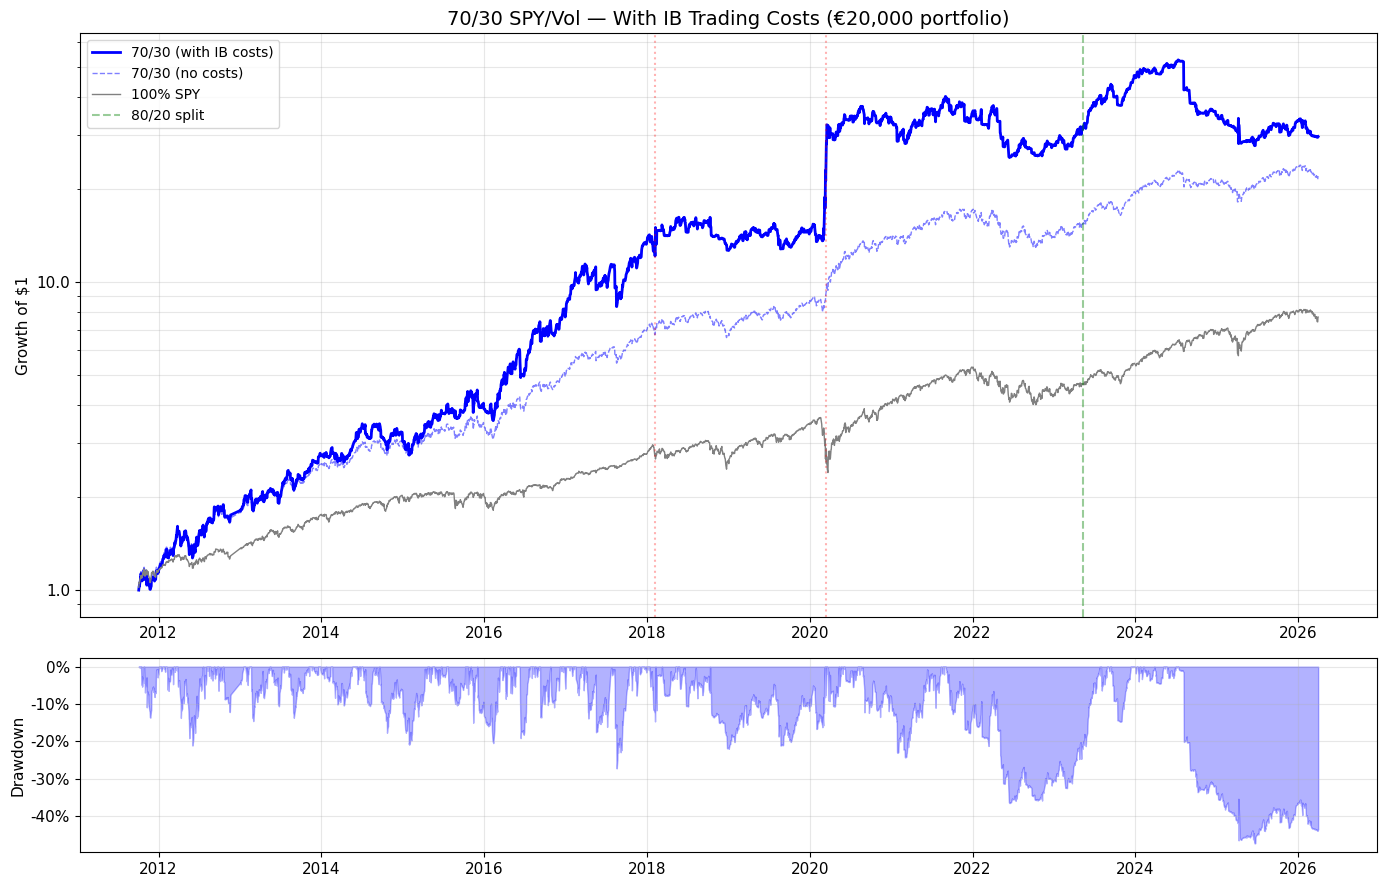


=== 70/30 Portfolio with IB Costs ===
  Terminal ($1)       : 29.70
  CAGR                : 26.7%
  Sharpe              : 0.89
  Max DD              : -47.4%
  Total Costs         : $107,854.08
  Costs/Start         : 501.65%
  Avg $/Trade         : $203.88
  Trades              : 529
  Cost drag:          34.42%


In [19]:
full_start = etf_data.index.min().strftime('%Y-%m-%d')
full_end = etf_data.index.max().strftime('%Y-%m-%d')

bt_cost, stats_cost = backtest_with_costs(
    data, sig_opt, PORTFOLIO_USD, w_vol=0.30, w_spy=0.70,
    start=full_start, end=full_end
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), height_ratios=[3, 1])

ax = axes[0]
ax.plot(bt_cost.index, bt_cost['equity_norm'], 'b-', lw=2, label='70/30 (with IB costs)')
ax.plot(bt_cost.index, bt_cost['nocost_equity'], 'b--', lw=1, alpha=0.5, label='70/30 (no costs)')
ax.plot(bt_cost.index, bt_cost['spy_only_eq'], color='gray', lw=1, label='100% SPY')
ax.axvline(train_end, color='green', ls='--', alpha=0.4, label='80/20 split')
for dt in ['2018-02-05', '2020-03-16']:
    evt = pd.Timestamp(dt)
    if evt >= bt_cost.index.min():
        ax.axvline(evt, color='red', ls=':', alpha=0.3)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}'))
ax.set_title(f'70/30 SPY/Vol — With IB Trading Costs (€{PORTFOLIO_EUR:,.0f} portfolio)', fontsize=14)
ax.set_ylabel('Growth of $1')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')

ax2 = axes[1]
eq = bt_cost['equity_norm']
dd = (eq / eq.cummax()) - 1
ax2.fill_between(dd.index, dd.values, 0, color='blue', alpha=0.3)
ax2.set_ylabel('Drawdown')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n=== 70/30 Portfolio with IB Costs ===')
for k, v in stats_cost.items():
    print(f'  {k:20s}: {v}')
print(f'  Cost drag:          {(bt_cost["equity_norm"].iloc[-1] / bt_cost["nocost_equity"].iloc[-1] - 1):.2%}')

## 18. Robustness Check 1: Fixed 2016 Split (Volmageddon & COVID OOS)

Complement to the main 80/20 split: train until end-2016, test 2017+.
Both Volmageddon and COVID are guaranteed out-of-sample.

Fixed split optimised: ST=0.0400, LT=-0.5000 (train Sharpe=1.51)


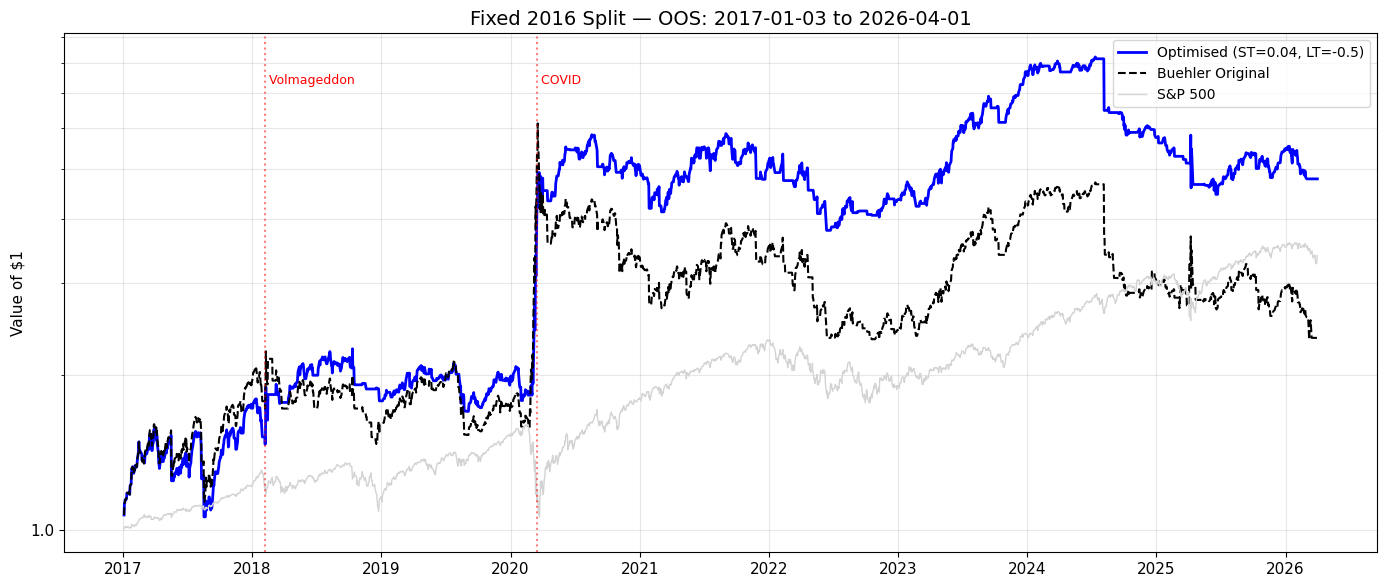

,Terminal ($1),CAGR,Vol (ann.),Sharpe,Sortino,Max DD,Trades,Days Short,Days Long,Days Cash,Period
Optimised,4.78,18.5%,36.9%,0.64,0.64,-45.7%,393,1505,43,776,2017-01-03 to 2026-04-01
Buehler,2.36,9.7%,41.9%,0.43,0.45,-61.8%,409,1645,100,579,2017-01-03 to 2026-04-01


In [20]:
FIXED_TRAIN_END  = '2016-12-30'
FIXED_TEST_START = '2017-01-03'

# Optimise on fixed train set
best_fixed_sharpe = -999
best_fixed_st, best_fixed_lt = BUEHLER_SHORT, BUEHLER_LONG
for st in np.arange(0.005, 0.10, 0.005):
    for lt in np.arange(-0.50, -0.02, 0.02):
        sig_tmp = generate_signals(data, st, lt)
        bt_tmp, s_tmp = backtest(data, sig_tmp, '', start=full_start, end=FIXED_TRAIN_END)
        if len(bt_tmp) == 0: continue
        s = float(s_tmp['Sharpe'])
        if s > best_fixed_sharpe:
            best_fixed_sharpe = s
            best_fixed_st, best_fixed_lt = round(st, 4), round(lt, 4)

print(f'Fixed split optimised: ST={best_fixed_st:.4f}, LT={best_fixed_lt:.4f} (train Sharpe={best_fixed_sharpe:.2f})')

# Test
sig_fixed = generate_signals(data, best_fixed_st, best_fixed_lt)
bt_fixed, stats_fixed = backtest(data, sig_fixed, 'Fixed 2016', start=FIXED_TEST_START, end=full_end)
bt_fixed_b, stats_fixed_b = backtest(data, sig_buehler, 'Buehler', start=FIXED_TEST_START, end=full_end)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(bt_fixed.index, bt_fixed['etf_equity'], 'b-', lw=2,
        label=f'Optimised (ST={best_fixed_st}, LT={best_fixed_lt})')
ax.plot(bt_fixed_b.index, bt_fixed_b['etf_equity'], 'k--', lw=1.5, label='Buehler Original')
ax.plot(bt_fixed.index, bt_fixed['spy_equity'], color='lightgray', lw=1, label='S&P 500')
for dt, lbl in [('2018-02-05', 'Volmageddon'), ('2020-03-16', 'COVID')]:
    evt = pd.Timestamp(dt)
    if evt >= bt_fixed.index.min() and evt <= bt_fixed.index.max():
        ax.axvline(evt, color='red', ls=':', alpha=0.5)
        ax.text(evt, ax.get_ylim()[1]*0.85, f' {lbl}', fontsize=9, color='red')
ax.set_title(f'Fixed 2016 Split — OOS: {FIXED_TEST_START} to {full_end}', fontsize=14)
ax.set_ylabel('Value of $1')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

comp_fixed = pd.DataFrame({'Optimised': stats_fixed, 'Buehler': stats_fixed_b}).T
display(comp_fixed)

## 19. Robustness Check 2: Walk-Forward Optimisation

Rolling 3-year train window, re-optimise yearly. Tests parameter stability over time.

In [21]:
def walk_forward(data, etf_start, etf_end, train_years=3, step_months=12):
    results = []
    opt_dates = pd.date_range(
        start=pd.Timestamp(etf_start) + pd.DateOffset(years=train_years),
        end=etf_end, freq=f'{step_months}MS'
    )
    for opt_date in opt_dates:
        tr_s = (opt_date - pd.DateOffset(years=train_years)).strftime('%Y-%m-%d')
        tr_e = (opt_date - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
        te_s = opt_date.strftime('%Y-%m-%d')
        te_e = (opt_date + pd.DateOffset(months=step_months) - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
        
        best_s, b_st, b_lt = -999, 0.02, -0.24
        for st in np.arange(0.005, 0.08, 0.01):
            for lt in np.arange(-0.50, -0.04, 0.04):
                sig_tmp = generate_signals(data, st, lt)
                bt_tmp, s_tmp = backtest(data, sig_tmp, '', start=tr_s, end=tr_e)
                if len(bt_tmp) == 0: continue
                s = float(s_tmp['Sharpe'])
                if s > best_s:
                    best_s, b_st, b_lt = s, round(st, 4), round(lt, 4)
        
        results.append({
            'opt_date': opt_date, 'train': f'{tr_s} to {tr_e}',
            'test': f'{te_s} to {te_e}',
            'opt_short': b_st, 'opt_long': b_lt, 'train_sharpe': best_s,
        })
    return pd.DataFrame(results)

wf_results = walk_forward(data, full_start, full_end)
print('=== Walk-Forward Windows ===')
print(wf_results[['opt_date', 'opt_short', 'opt_long', 'train_sharpe']].to_string(index=False))

=== Walk-Forward Windows ===
  opt_date  opt_short  opt_long  train_sharpe
2014-11-01      0.025     -0.50          1.52
2015-11-01      0.025     -0.50          1.28
2016-11-01      0.025     -0.38          1.37
2017-11-01      0.055     -0.50          1.59
2018-11-01      0.055     -0.50          1.42
2019-11-01      0.055     -0.50          0.96
2020-11-01      0.075     -0.30          1.27
2021-11-01      0.075     -0.42          1.23
2022-11-01      0.015     -0.42          0.95
2023-11-01      0.015     -0.50          0.46
2024-11-01      0.035     -0.50          0.17
2025-11-01      0.035     -0.38          0.52


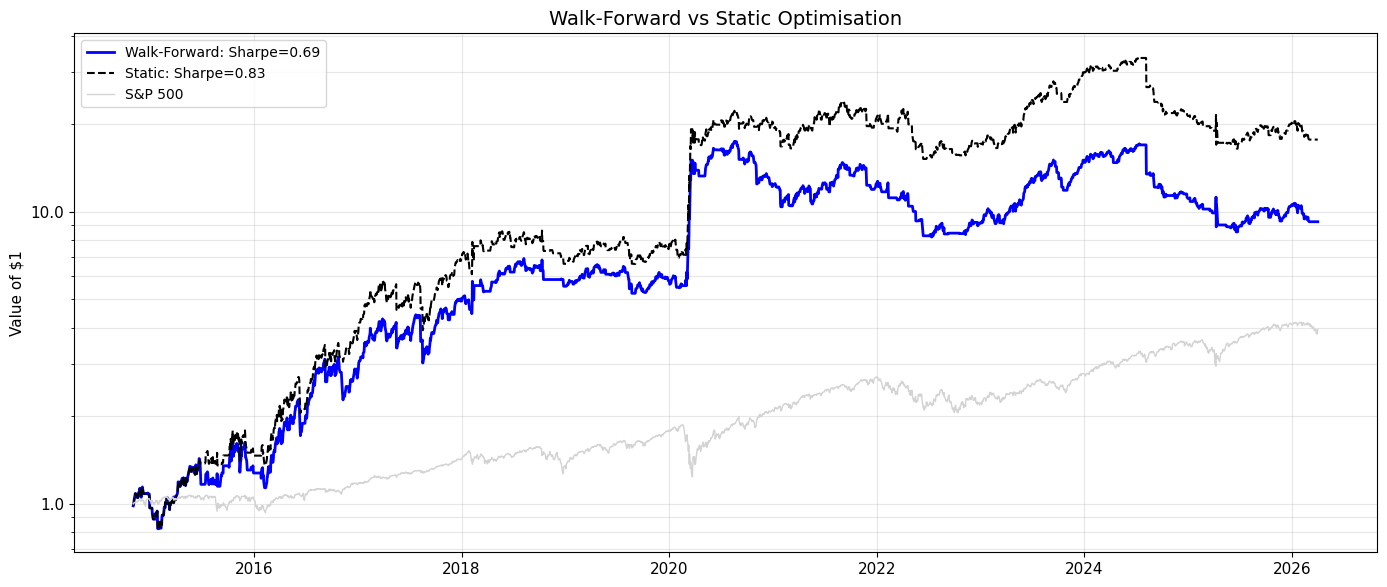

In [22]:
# Stitch together OOS signals
wf_signal = pd.Series('CASH', index=data.index)
for _, row in wf_results.iterrows():
    ts, te = row['test'].split(' to ')
    sig_tmp = generate_signals(data, row['opt_short'], row['opt_long'])
    mask = (data.index >= ts) & (data.index <= te)
    wf_signal[mask] = sig_tmp[mask]

wf_start = wf_results.iloc[0]['test'].split(' to ')[0]
bt_wf, stats_wf = backtest(data, wf_signal, 'Walk-Forward', start=wf_start, end=full_end)
bt_static, stats_static = backtest(data, sig_opt, 'Static Opt', start=wf_start, end=full_end)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(bt_wf.index, bt_wf['etf_equity'], 'b-', lw=2, label=f'Walk-Forward: Sharpe={stats_wf["Sharpe"]}')
ax.plot(bt_static.index, bt_static['etf_equity'], 'k--', lw=1.5, label=f'Static: Sharpe={stats_static["Sharpe"]}')
ax.plot(bt_wf.index, bt_wf['spy_equity'], color='lightgray', lw=1, label='S&P 500')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}'))
ax.set_title('Walk-Forward vs Static Optimisation', fontsize=14)
ax.set_ylabel('Value of $1')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 20. Robustness Check 3: Subperiod Analysis

Annual performance of the 70/30 blend vs pure SPY. Shows consistency.

In [23]:
# Compute 70/30 blend return from bt_full
blend_ret = 0.30 * bt_full['etf_ret'] + 0.70 * bt_full['SPY_ret']

annual_stats = []
for yr in sorted(bt_full.index.year.unique()):
    br = blend_ret[bt_full.index.year == yr].dropna()
    sr = bt_full.loc[bt_full.index.year == yr, 'SPY_ret'].dropna()
    if len(br) < 20: continue
    
    b_eq = (1 + br).cumprod()
    s_eq = (1 + sr).cumprod()
    b_ret = b_eq.iloc[-1] - 1
    s_ret = s_eq.iloc[-1] - 1
    b_vol = br.std() * np.sqrt(252)
    b_sharpe = (br.mean() * 252) / b_vol if b_vol > 0 else 0
    b_dd = (b_eq / b_eq.cummax() - 1).min()
    s_dd = (s_eq / s_eq.cummax() - 1).min()
    
    in_train = pd.Timestamp(f'{yr}-06-30') <= train_end
    
    annual_stats.append({
        'Year': yr, 'Sample': 'TRAIN' if in_train else 'TEST',
        '70/30 Ret': f'{b_ret:.1%}', 'SPY Ret': f'{s_ret:.1%}',
        '70/30 Sharpe': f'{b_sharpe:.2f}',
        '70/30 MaxDD': f'{b_dd:.1%}', 'SPY MaxDD': f'{s_dd:.1%}',
        'Beats SPY': '✅' if b_ret > s_ret else '❌',
    })

annual_df = pd.DataFrame(annual_stats).set_index('Year')
display(annual_df)

oos_years = annual_df[annual_df['Sample'] == 'TEST']
n_win = (oos_years['Beats SPY'] == '✅').sum()
print(f'\nOOS years 70/30 beats SPY: {n_win}/{len(oos_years)}')

,Sample,70/30 Ret,SPY Ret,70/30 Sharpe,70/30 MaxDD,SPY MaxDD,Beats SPY
Year,,,,,,,
2011,TRAIN,15.3%,12.4%,1.78,-13.2%,-9.6%,✅
2012,TRAIN,46.8%,12.6%,1.76,-17.7%,-9.7%,✅
2013,TRAIN,49.9%,36.3%,2.27,-9.6%,-5.6%,✅
2014,TRAIN,13.6%,13.5%,0.88,-11.1%,-7.3%,✅
2015,TRAIN,16.3%,1.2%,0.83,-10.1%,-11.9%,✅
2016,TRAIN,45.0%,12.0%,1.88,-10.4%,-9.2%,✅
2017,TRAIN,40.7%,21.7%,2.13,-11.5%,-2.6%,✅
2018,TRAIN,-1.9%,-4.6%,-0.04,-17.8%,-19.3%,✅
2019,TRAIN,26.4%,31.2%,1.83,-9.8%,-6.6%,❌



OOS years 70/30 beats SPY: 1/4


## 21. Robustness Check 4: Execution Delay Sensitivity

What if you can't trade next-day open? Test +1 and +2 day additional delays.

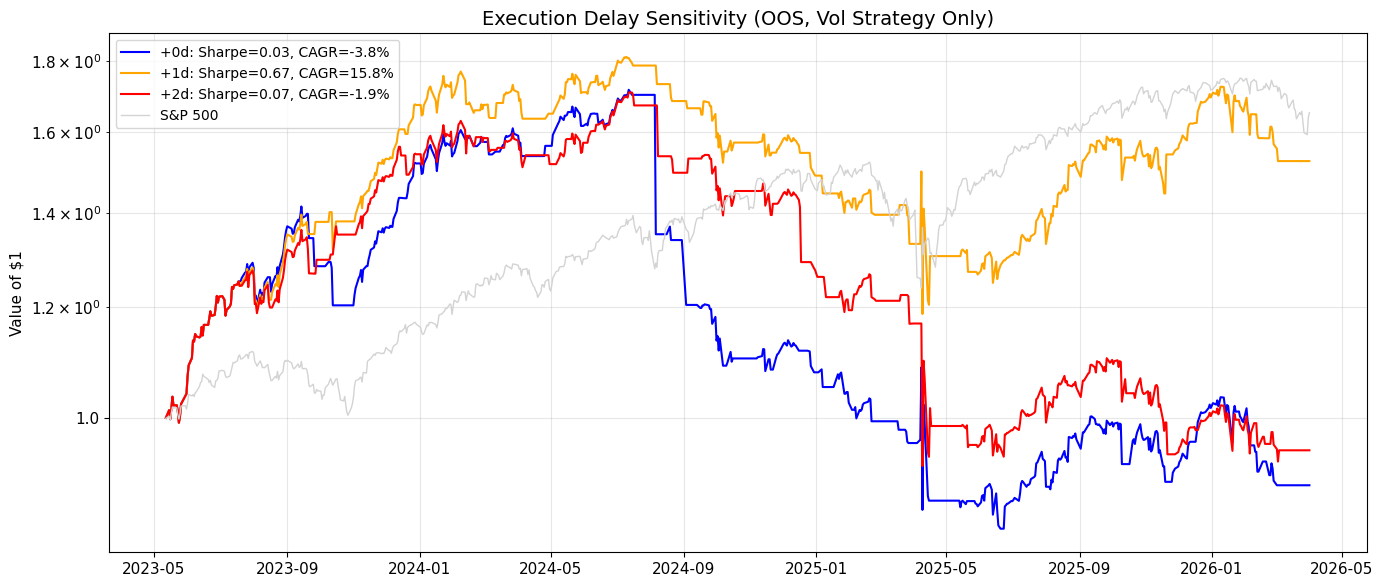

,Terminal ($1),CAGR,Vol (ann.),Sharpe,Sortino,Max DD,Trades,Days Short,Days Long,Days Cash,Period
Delay,,,,,,,,,,,
+0d,0.89,-3.8%,29.9%,0.03,0.02,-51.5%,116,464,10,250,2023-05-12 to 2026-04-01
+1d,1.53,15.8%,27.7%,0.67,0.59,-34.5%,116,465,10,249,2023-05-12 to 2026-04-01
+2d,0.95,-1.9%,27.5%,0.07,0.06,-45.9%,116,466,10,248,2023-05-12 to 2026-04-01


In [24]:
def signals_delayed(data, short_thresh, long_thresh, delay=0):
    prev_roll = data['daily_roll'].shift(1 + delay)
    signal = pd.Series('CASH', index=data.index)
    signal[prev_roll >= short_thresh] = 'SVXY'
    signal[prev_roll <= long_thresh]  = 'VIXY'
    return signal

delay_results = []
fig, ax = plt.subplots(figsize=(14, 6))

for delay, color in [(0, 'blue'), (1, 'orange'), (2, 'red')]:
    sig_d = signals_delayed(data, OPT_SHORT, OPT_LONG, delay=delay)
    bt_d, stats_d = backtest(data, sig_d, f'+{delay}d', start=test_start.strftime('%Y-%m-%d'), end=full_end)
    if len(bt_d) > 0:
        ax.plot(bt_d.index, bt_d['etf_equity'], color=color, lw=1.5,
                label=f'+{delay}d: Sharpe={stats_d["Sharpe"]}, CAGR={stats_d["CAGR"]}')
        delay_results.append({'Delay': f'+{delay}d', **stats_d})

ax.plot(bt_d.index, bt_d['spy_equity'], color='lightgray', lw=1, label='S&P 500')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}'))
ax.set_title('Execution Delay Sensitivity (OOS, Vol Strategy Only)', fontsize=14)
ax.set_ylabel('Value of $1')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

display(pd.DataFrame(delay_results).set_index('Delay'))

## 22. Robustness Check 5: Parameter Neighbourhood Stability

Test all thresholds within ±30% of the optimum on OOS data.
If >80% have positive Sharpe, the strategy isn't curve-fitted.

Parameter neighbourhood (OOS): 160 combos
Sharpe: [-0.09, 0.46], mean=0.20, std=0.16
% positive Sharpe: 91%


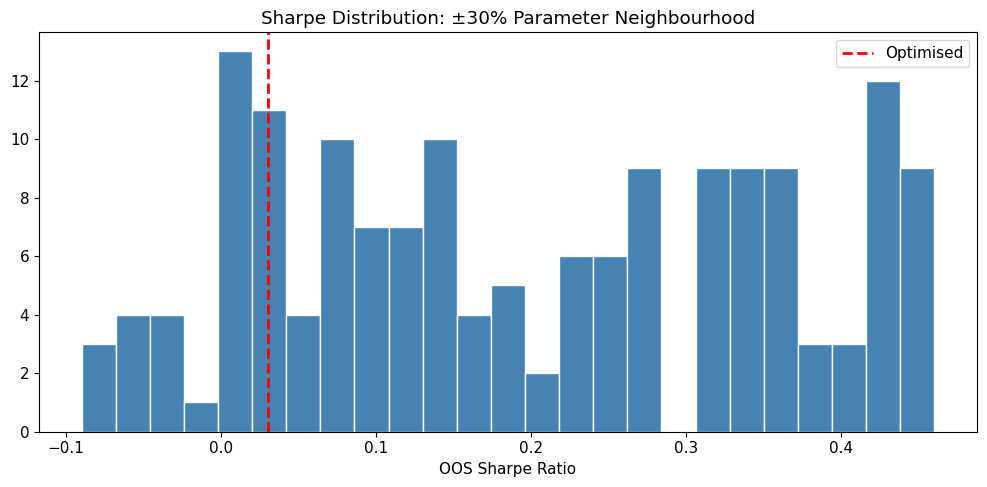

In [25]:
st_range = np.arange(OPT_SHORT * 0.7, OPT_SHORT * 1.3 + 0.001, 0.002)
lt_range = np.arange(OPT_LONG * 1.3, OPT_LONG * 0.7 + 0.001, 0.02)

neighbourhood = []
for st in st_range:
    for lt in lt_range:
        sig_n = generate_signals(data, st, lt)
        bt_n, stats_n = backtest(data, sig_n, '', start=test_start.strftime('%Y-%m-%d'), end=full_end)
        if len(bt_n) == 0: continue
        neighbourhood.append({
            'short': round(st, 4), 'long': round(lt, 3),
            'sharpe': float(stats_n['Sharpe']),
        })

nb_df = pd.DataFrame(neighbourhood)

print(f'Parameter neighbourhood (OOS): {len(nb_df)} combos')
print(f'Sharpe: [{nb_df["sharpe"].min():.2f}, {nb_df["sharpe"].max():.2f}], '
      f'mean={nb_df["sharpe"].mean():.2f}, std={nb_df["sharpe"].std():.2f}')
print(f'% positive Sharpe: {(nb_df["sharpe"] > 0).mean():.0%}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(nb_df['sharpe'], bins=25, color='steelblue', edgecolor='white')
ax.axvline(float(stats_opt['Sharpe']), color='red', ls='--', lw=2, label='Optimised')
ax.set_xlabel('OOS Sharpe Ratio')
ax.set_title('Sharpe Distribution: ±30% Parameter Neighbourhood')
ax.legend()
plt.tight_layout()
plt.show()

## 23. Robustness Check 6: Permutation Test (Random Signals)

1,000 random signal sequences with the same SVXY/VIXY/CASH proportions.
If our Sharpe is significantly better → the timing signal matters.

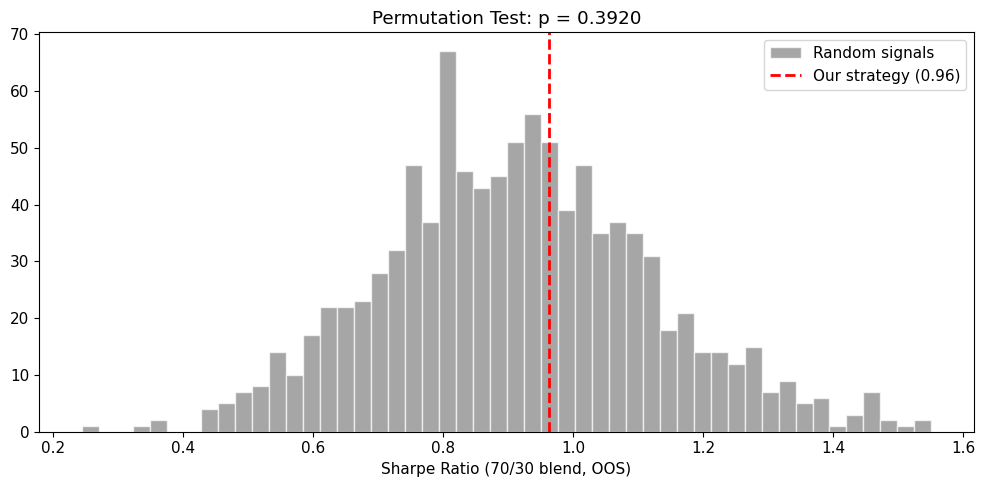

Strategy Sharpe: 0.963, Random mean: 0.912
p-value: 0.3920 → Not significant ❌


In [26]:
np.random.seed(42)
N_PERMS = 1000

oos_range = data.loc[test_start.strftime('%Y-%m-%d'):full_end].dropna(subset=['SVXY_ret','VIXY_ret']).copy()
oos_sig = sig_opt.reindex(oos_range.index)

n_svxy = (oos_sig == 'SVXY').sum()
n_vixy = (oos_sig == 'VIXY').sum()
n_cash = (oos_sig == 'CASH').sum()
total = len(oos_sig)
probs = [n_svxy/total, n_vixy/total, n_cash/total]

# Actual strategy OOS Sharpe (70/30 blend)
actual_vol_ret = np.zeros(total)
actual_vol_ret[oos_sig.values == 'SVXY'] = oos_range['SVXY_ret'].values[oos_sig.values == 'SVXY']
actual_vol_ret[oos_sig.values == 'VIXY'] = oos_range['VIXY_ret'].values[oos_sig.values == 'VIXY']
actual_blend = 0.30 * actual_vol_ret + 0.70 * oos_range['SPY_ret'].values
actual_sharpe = (np.nanmean(actual_blend) * 252) / (np.nanstd(actual_blend) * np.sqrt(252))

random_sharpes = []
for _ in range(N_PERMS):
    rand_sig = np.random.choice(['SVXY', 'VIXY', 'CASH'], size=total, p=probs)
    rand_ret = np.zeros(total)
    rand_ret[rand_sig == 'SVXY'] = oos_range['SVXY_ret'].values[rand_sig == 'SVXY']
    rand_ret[rand_sig == 'VIXY'] = oos_range['VIXY_ret'].values[rand_sig == 'VIXY']
    blend = 0.30 * rand_ret + 0.70 * oos_range['SPY_ret'].values
    vol = np.nanstd(blend) * np.sqrt(252)
    random_sharpes.append((np.nanmean(blend) * 252) / vol if vol > 0 else 0)

random_sharpes = np.array(random_sharpes)
pval = (random_sharpes >= actual_sharpe).mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(random_sharpes, bins=50, color='gray', edgecolor='white', alpha=0.7, label='Random signals')
ax.axvline(actual_sharpe, color='red', lw=2, ls='--', label=f'Our strategy ({actual_sharpe:.2f})')
ax.set_xlabel('Sharpe Ratio (70/30 blend, OOS)')
ax.set_title(f'Permutation Test: p = {pval:.4f}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'Strategy Sharpe: {actual_sharpe:.3f}, Random mean: {random_sharpes.mean():.3f}')
print(f'p-value: {pval:.4f} → {"Significant ✅" if pval < 0.05 else "Not significant ❌"}')

## 24. Robustness Scorecard

In [27]:
print('=' * 65)
print('ROBUSTNESS SCORECARD')
print('=' * 65)

cost_drag = bt_cost['equity_norm'].iloc[-1] / bt_cost['nocost_equity'].iloc[-1] - 1

checks = [
    ('Trading costs (IB €20k)',
     f'Drag: {cost_drag:.1%}',
     abs(cost_drag) < 0.15),
    ('Fixed 2016 split (Volmag+COVID OOS)',
     f'Sharpe={stats_fixed["Sharpe"]}',
     float(stats_fixed['Sharpe']) > 0),
    ('Walk-forward optimisation',
     f'Sharpe={stats_wf["Sharpe"]}',
     float(stats_wf['Sharpe']) > 0),
    ('Subperiod consistency',
     f'{n_win}/{len(oos_years)} OOS years beat SPY',
     n_win > len(oos_years) * 0.4),
    ('Execution delay (+1d)',
     f'Sharpe={delay_results[1]["Sharpe"] if len(delay_results) > 1 else "N/A"}',
     len(delay_results) > 1 and float(delay_results[1].get('Sharpe', '0')) > 0),
    ('Parameter neighbourhood (±30%)',
     f'{(nb_df["sharpe"] > 0).mean():.0%} positive Sharpe',
     (nb_df['sharpe'] > 0).mean() > 0.70),
    ('Permutation test (p<0.05)',
     f'p = {pval:.4f}',
     pval < 0.05),
]

for name, detail, passed in checks:
    print(f'  {"✅" if passed else "❌"} {name:40s} | {detail}')

n_passed = sum(1 for _,_,p in checks if p)
print(f'\nPassed: {n_passed}/{len(checks)}')
if n_passed >= 5:
    print('\n→ Strategy appears robust enough for live trading with appropriate position sizing.')
elif n_passed >= 3:
    print('\n→ Strategy shows promise but has weaknesses. Proceed with caution and smaller sizing.')
else:
    print('\n→ Strategy may be overfit. Reconsider before going live.')

ROBUSTNESS SCORECARD
  ❌ Trading costs (IB €20k)                  | Drag: 34.4%
  ✅ Fixed 2016 split (Volmag+COVID OOS)      | Sharpe=0.64
  ✅ Walk-forward optimisation                | Sharpe=0.69
  ❌ Subperiod consistency                    | 1/4 OOS years beat SPY
  ✅ Execution delay (+1d)                    | Sharpe=0.67
  ✅ Parameter neighbourhood (±30%)           | 91% positive Sharpe
  ❌ Permutation test (p<0.05)                | p = 0.3920

Passed: 4/7

→ Strategy shows promise but has weaknesses. Proceed with caution and smaller sizing.


## Notes

1. **Pre-2008 price fix**: Old CBOE archive files (2006–2007) had prices ×10. Individual rows
   with Settle > 90 are divided by 10 (per-row, not per-contract, to handle mixed scaling).

2. **2012/2013 Settle=0 gap**: Some early new-format files have Settle=0 with actual prices
   in the Close column. The loader falls back to Close automatically.

3. **SVXY leverage change**: After Volmageddon (Feb 5, 2018), SVXY changed from −1× to −0.5×.
   This is in our test set — the strategy is evaluated honestly against this structural break.

4. **Futures returns**: Roll-day jumps (when F1 switches to a new contract) are zeroed out
   to avoid spurious returns in the futures-only comparison.

5. **Transaction costs** not included (consistent with Buehler).

6. **Portfolio rebalancing**: Daily constant-weight (practical implementation would use monthly).